In [1]:
import pandas as pd
import numpy as np
import librosa
import os
import matplotlib.pyplot as plt
import pywt
import joblib
import soundfile as sf

from sklearn.metrics import classification_report

from config import SAMPLING_RATE, HIGH_CUT

In [6]:
df = pd.read_csv('./dataset/ciclos/filtrado/train.csv')

In [7]:
df.head(10)

,cycle_wav_file,label
0,158_1p3_Pr_mc_AKGC417L_cycle4.wav,1
1,146_8p3_Lr_mc_AKGC417L_cycle4.wav,1
2,154_1b3_Tc_mc_AKGC417L_cycle4.wav,0
3,158_1p4_Pr_mc_AKGC417L_cycle2.wav,1
4,207_3b2_Pl_mc_AKGC417L_cycle6.wav,0
5,130_2b3_Ll_mc_AKGC417L_cycle9.wav,1
6,130_1p3_Lr_mc_AKGC417L_cycle5.wav,1
7,182_1b1_Tc_sc_Meditron_cycle2.wav,1
8,154_4b4_Lr_mc_AKGC417L_cycle7.wav,1
9,151_2p2_Ll_mc_AKGC417L_cycle6.wav,1


In [8]:
ciclos_filenames = df['cycle_wav_file'].values

ciclos = []
for filename in ciclos_filenames:
    y, sr = librosa.load(os.path.join('./dataset/ciclos/', filename), sr=SAMPLING_RATE)
    ciclos.append(y)

In [41]:
def plot_mel_spectrogram(y, sr=SAMPLING_RATE, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', ax=ax);

In [10]:
ciclos_propios = []
for filename in os.listdir('./audios_propios/ciclos_energy_based'):
    y, sr = librosa.load(os.path.join('./audios_propios/ciclos_energy_based', filename), sr=SAMPLING_RATE)
    ciclos_propios.append(y)

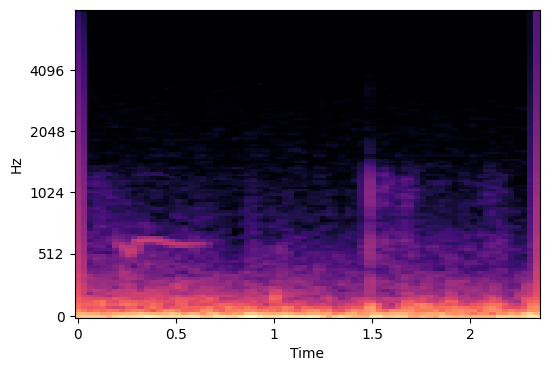

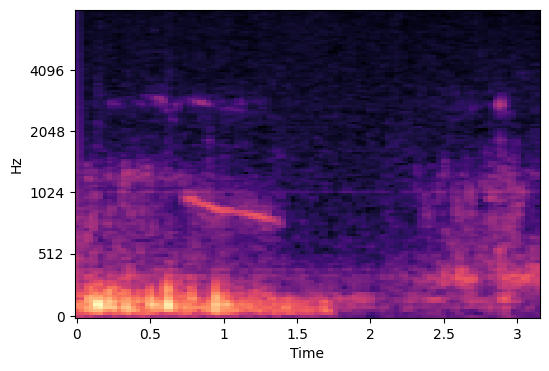

In [42]:
plot_mel_spectrogram(ciclos[0])
plot_mel_spectrogram(ciclos_propios[23])

Tengo que lograr que el audio de abajo se parezca al de arriba

Una opcion es usar un Filtro Pasa Bajos  
Otra es con Wavelet Denoising

In [12]:
def low_pass_filter(y, sr=SAMPLING_RATE, cutoff=HIGH_CUT):
    from scipy.signal import butter, filtfilt
    nyquist = 0.5 * sr
    normal_cutoff = cutoff / nyquist
    b, a = butter(5, normal_cutoff, btype='low', analog=False)
    y_filtered = filtfilt(b, a, y)
    return y_filtered

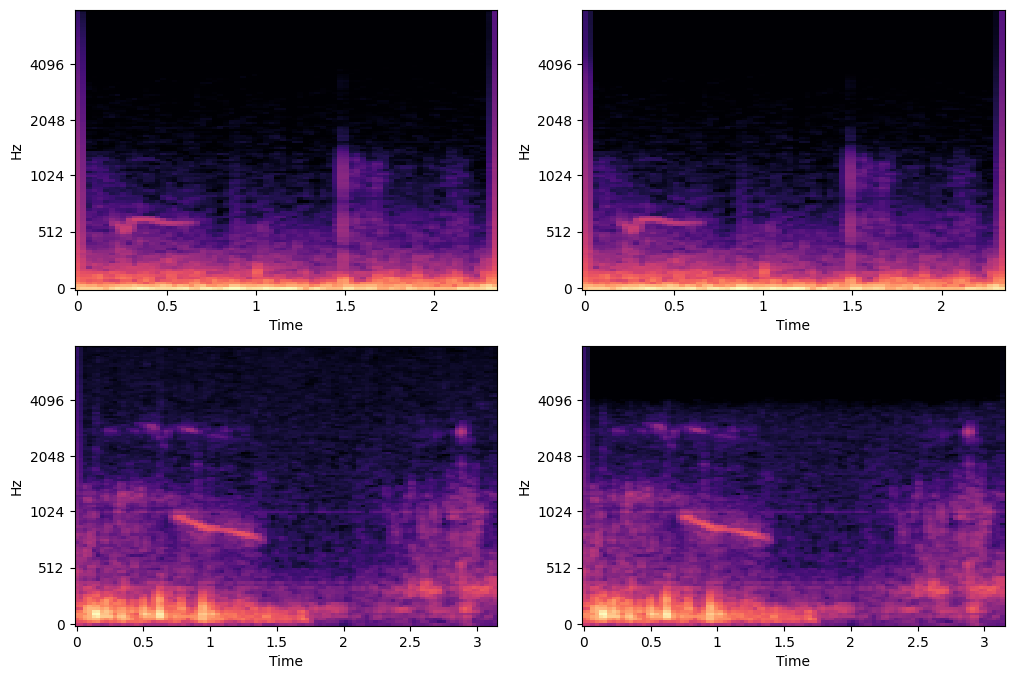

In [44]:
_, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_mel_spectrogram(ciclos[0], ax=axes[0, 0])
plot_mel_spectrogram(low_pass_filter(ciclos[0]), ax=axes[0, 1])
plot_mel_spectrogram(ciclos_propios[23], ax=axes[1, 0])
plot_mel_spectrogram(low_pass_filter(ciclos_propios[23]), ax=axes[1, 1])

Habría que definir el corte más bajo, pero eso podría hacernos perder información

Wavelet denoising

In [14]:
def wavelet_denoise(signal, wavelet='db4', level=4, threshold_method='soft'):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745  # estimación del ruido
    uthresh = sigma * np.sqrt(2 * np.log(len(signal)))
    coeffs_thresh = [coeffs[0]] + [
        pywt.threshold(c, value=uthresh, mode=threshold_method)
        for c in coeffs[1:]
    ]
    return pywt.waverec(coeffs_thresh, wavelet)

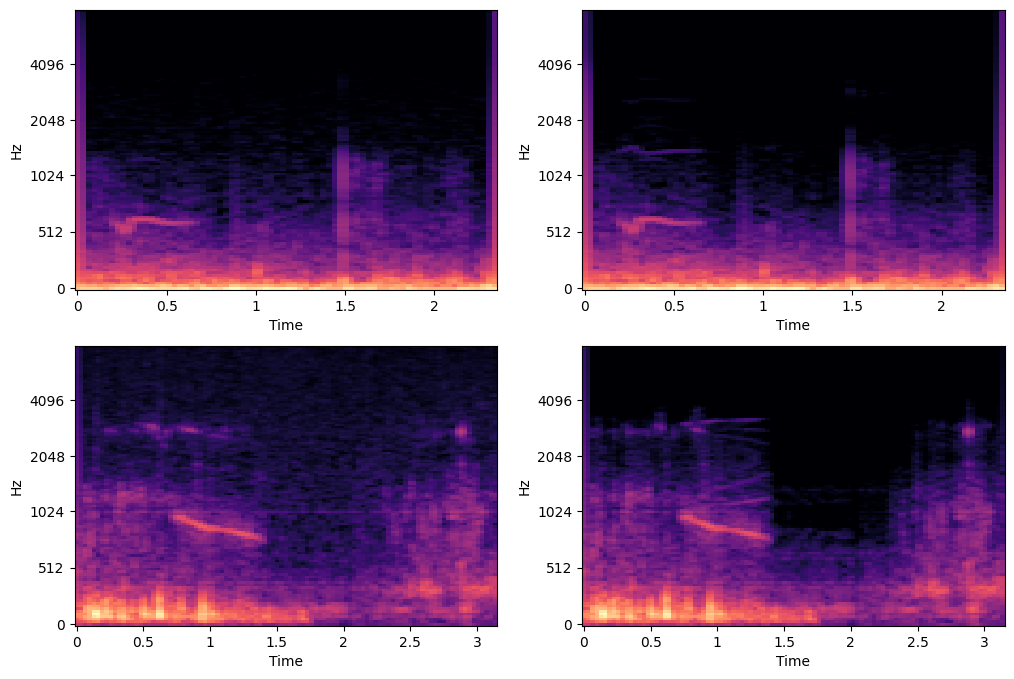

In [45]:
_, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_mel_spectrogram(ciclos[0], ax=axes[0, 0])
plot_mel_spectrogram(low_pass_filter(wavelet_denoise(ciclos[0])), ax=axes[0, 1])
plot_mel_spectrogram(ciclos_propios[23], ax=axes[1, 0])
plot_mel_spectrogram(low_pass_filter(wavelet_denoise(ciclos_propios[23])), ax=axes[1, 1])


Aparecen detalles que antes no se podían apreciar. Probemos con más audios

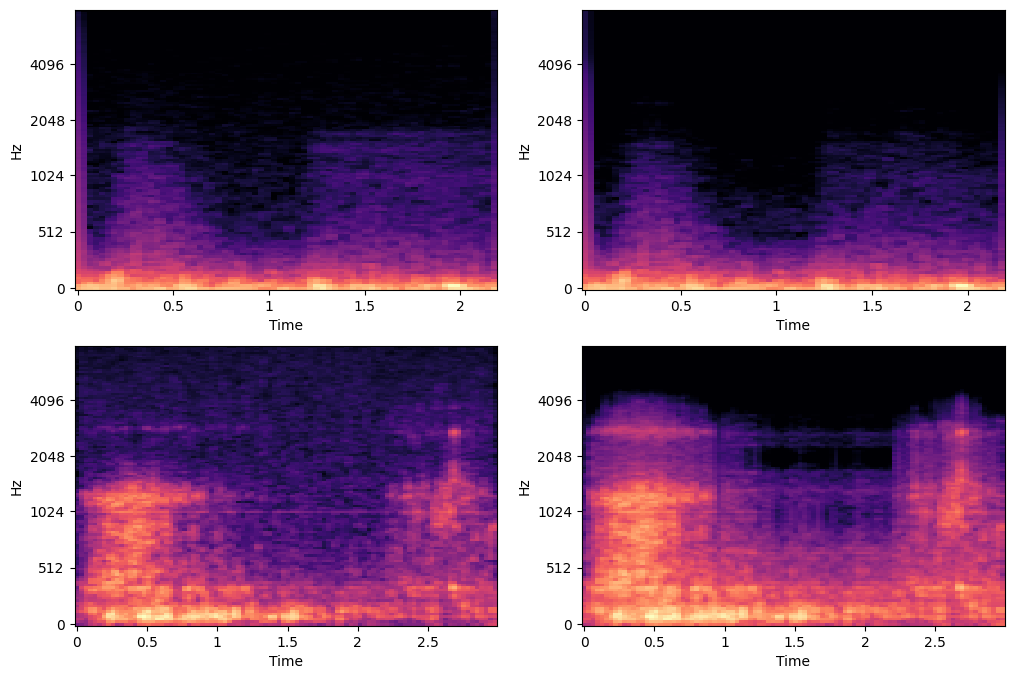

In [64]:
_, axes = plt.subplots(2, 2, figsize=(12, 8))

ciclo_icbhi = 10
ciclo_propio = 21

plot_mel_spectrogram(ciclos[ciclo_icbhi], ax=axes[0, 0])
plot_mel_spectrogram(low_pass_filter(wavelet_denoise(ciclos[ciclo_icbhi])), ax=axes[0, 1])
plot_mel_spectrogram(ciclos_propios[ciclo_propio], ax=axes[1, 0])
plot_mel_spectrogram(low_pass_filter(wavelet_denoise(ciclos_propios[ciclo_propio])), ax=axes[1, 1])

Guardo los ciclos procesados

In [73]:
ciclos_propios_filenames = os.listdir('./audios_propios/ciclos_energy_based')
ciclos_propios_filenames = [os.path.splitext(f)[0] for f in ciclos_propios_filenames]

In [ ]:
denoised_ciclos_propios = [wavelet_denoise(c) for c in ciclos_propios] # el modelo ya le aplica el low pass filter

os.makedirs('./audios_propios/ciclos_eb_wavelet_denoised', exist_ok=True)

for (c, filename) in zip(denoised_ciclos_propios, ciclos_propios_filenames):
    sf.write(f'./audios_propios/ciclos_eb_wavelet_denoised/{filename}.wav', c, SAMPLING_RATE)


Pruebo el modelo random forest con los audios desonorizados (?)

In [2]:
modelo = joblib.load('./modelos/features_rf.pkl')

In [3]:
path = './audios_propios/ciclos_eb_wavelet_denoised'
files = os.listdir(path)

df_audios_propios = pd.DataFrame(files, columns=['cycle_wav_file'])

df_audios_propios['label'] = np.where(df_audios_propios['cycle_wav_file'].str.contains('respiracion4_ciclo_5'), 1, 0)

In [4]:
archivos = df_audios_propios['cycle_wav_file'].tolist()

X_propios_paths = [os.path.join(path, f) for f in archivos]
y_propios = df_audios_propios['label'].values

In [5]:
y_propios_pred = modelo.predict(X_propios_paths)
y_propios_proba_pred = modelo.predict_proba(X_propios_paths)[:, 1]

In [6]:
print(classification_report(y_propios, y_propios_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        48
           1       0.00      0.00      0.00         1

    accuracy                           0.98        49
   macro avg       0.49      0.50      0.49        49
weighted avg       0.96      0.98      0.97        49



c:\Users\nazar\Clasificador-Respiracion\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nazar\Clasificador-Respiracion\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\nazar\Clasificador-Respiracion\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

In [7]:
df_audios_propios['predicted'] = y_propios_pred
df_audios_propios['probability'] = y_propios_proba_pred.round(2)
df_audios_propios

,cycle_wav_file,label,predicted,probability
0,respiracion1_ciclo_1.wav,0,0,0.16
1,respiracion1_ciclo_2.wav,0,0,0.25
2,respiracion1_ciclo_3.wav,0,0,0.26
3,respiracion1_ciclo_4.wav,0,0,0.26
4,respiracion1_ciclo_5.wav,0,0,0.28
5,respiracion1_ciclo_6.wav,0,0,0.22
6,respiracion1_ciclo_7.wav,0,0,0.23
7,respiracion2_ciclo_1.wav,0,0,0.21
8,respiracion2_ciclo_2.wav,0,0,0.27
9,respiracion2_ciclo_3.wav,0,0,0.22


Hay que probar entrenando un modelo usando el wavelet denoiser